## Acceso a los ficheros de volcado de Reddit (Reddit Dump) para la realización de la práctica 2 de Procesamiento del Lenguaje Natural Escrito

Debido a las últimas limitaciones en la red Reddit para conseguir la API Key necesaria para su acceso, se ha decidido obtener la información a partir de un volcado de Reddit del año 2025 donde se han seleccionado un conjunto de subreddits con todos sus *submissions* y *comments*.

Estos volcados de Reddit se dividen en dos ficheros con formato ZST:
* El fichero RS_2025.zst contiene todas las *submissions* (hilos o posts) por los subreddits seleccionados junto con toda su información.
* El fichero RC_2025.zst tiene todos los *comments* por cada uno de las *submissions* de los subreddits seleccionados y que aparecen en RS_2025.zst.

Por otro lado, están los volcados de 2025 del subreddit "OpinionesPolemicas" para poder realizar un apartado de la práctica 2 con los siguientes ficheros:
* RS_OpinionesPolemicas2025.zst
* RC_OpinionesPolemicas2025.zst

## Estructura de los datos

### Submissions (RS_2025.zst)

Cada línea del fichero es un objeto JSON con los siguientes atributos principales:

| Atributo | Descripción |
|----------|-------------|
| `id` | Identificador único de la submission |
| `subreddit` | Nombre del subreddit |
| `author` | Usuario que creó la submission |
| `title` | Título del post o hilo|
| `selftext` | Contenido del post o hilo (si es de tipo texto) |
| `url` | Enlace asociado (si es de tipo link) |
| `score` | Puntuación (upvotes - downvotes) |
| `num_comments` | Número de comentarios |
| `created_utc` | Fecha de creación (timestamp Unix) |
| `permalink` | Enlace permanente al post o hilo |
| `is_self` | `true` si es un post o hilo de texto, `false` si es un enlace |
| `over_18` | `true` si está marcado como contenido adulto |
| `edited` | Timestamp de edición o `false` si no fue editado |
| `stickied` | `true` si está fijado en el subreddit |
| `locked` | `true` si los comentarios están bloqueados |
| `spoiler` | `true` si contiene spoilers |
| `link_flair_text` | Etiqueta (flair) del post o hilo |

### Comments (RC_2025.zst)

Cada línea del fichero es un objeto JSON con los siguientes atributos principales:

| Atributo | Descripción |
|----------|-------------|
| `id` | Identificador único del comentario |
| `link_id` | ID de la submission a la que pertenece (formato `t3_xxxxx`) |
| `parent_id` | ID del elemento padre: `t3_xxxxx` si es respuesta directa al post, `t1_xxxxx` si es respuesta a otro comentario |
| `subreddit` | Nombre del subreddit |
| `author` | Usuario que escribió el comentario |
| `body` | Contenido del comentario |
| `score` | Puntuación (upvotes - downvotes) |
| `created_utc` | Fecha de creación (timestamp Unix) |
| `is_submitter` | `true` si el autor es el mismo que creó la submission |
| `edited` | Timestamp de edición o `false` si no fue editado |
| `stickied` | `true` si está fijado |
| `controversiality` | `1` si el comentario es controvertido, `0` en caso contrario |
| `distinguished` | Indica rol especial (`moderator`, `admin`) o `null` |

## Relación entre ficheros

Para vincular comentarios con sus submissions, se usa el campo `link_id` de los comentarios, que corresponde al `id` de la submission con el prefijo `t3_`. Por ejemplo, un comentario con `link_id: "t3_abc123"` pertenece a la submission con `id: "abc123"`.

In [1]:
# Descargamos los dos ficheros desde el servidor para procesarlos.
#
# Ficheros:
#   - RS_2025.zst: Submissions (~9,2 GB) - Contiene los posts o hilos de los subreddits seleccionados
#   - RC_2025.zst: Comments (~55 GB) - Contiene todos los comentarios de dichas submissions
#   - RS_OpinionesPolemicas2025.zst: Submissions (~5,6 MB) - Contiene los posts o hilos del subreddit "OpinionesPolemicas"
#   - RC_OpinionesPolemicas2025.zst: Comments (~22,5 GB) - Contiene todos los comentarios de las submissions de "OpinionesPolemicas"

# !wget --no-check-certificate  https://valencia.inf.um.es/valencia-plne/RS_2025.zst
# !wget --no-check-certificate  https://valencia.inf.um.es/valencia-plne/RC_2025.zst

submissions_file = "RS_2025.zst"
comments_file = "RC_2025.zst"

# !wget --no-check-certificate https://valencia.inf.um.es/valencia-plne/RS_OpinionesPolemicas2025.zst
# !wget --no-check-certificate https://valencia.inf.um.es/valencia-plne/RC_OpinionesPolemicas2025.zst

# submissions_file = "RS_OpinionesPolemicas2025.zst"
# comments_file = "RC_OpinionesPolemicas2025.zst"


## Funciones para procesar los ficheros ZST

A continuación se definen las tres funciones principales para trabajar con los dumps de Reddit:

### `stream_zst_file(filepath)`
Generador que lee un fichero `.zst` línea por línea y devuelve cada objeto JSON. Utiliza descompresión en streaming para no cargar todo el fichero en memoria, lo cual es esencial dado el tamaño de los dumps.

### `extract_submissions(filepath, subreddit, n_submissions, min_comments)`
Extrae submissions de un subreddit específico, capturando todos los atributos disponibles en el dump. Parámetros:
- `filepath`: Ruta al fichero RS_2025.zst
- `subreddit`: Nombre del subreddit (sin el prefijo "r/")
- `n_submissions`: Número máximo de submissions a extraer (por defecto 3)
- `min_comments`: Filtra submissions con al menos este número de comentarios (por defecto 250)

Atributos más importantes que se obtendrán para los submissions:
| Atributo | Descripción |
|----------|-------------|
| `id` | Identificador único de la submission |
| `subreddit` | Nombre del subreddit |
| `author` | Usuario que creó la submission |
| `title` | Título del post o hilo|
| `selftext` | Contenido del post o hilo (si es de tipo texto) |
| `url` | Enlace asociado (si es de tipo link) |
| `score` | Puntuación (upvotes - downvotes) |
| `num_comments` | Número de comentarios |
| `created_utc` | Fecha de creación (timestamp Unix) |
| `is_self` | `true` si es un post o hilo de texto, `false` si es un enlace |
| `link_flair_text` | Etiqueta (flair) del post o hilo |

Además de estos atributos, añade los campos calculados `name` (id con prefijo `t3_`), `created_datetime` (fecha en formato ISO 8601) y `comments` (lista vacía que se rellenará posteriormente).

### `extract_comments_for_submissions(filepath, submissions, num_comments)`
Busca los comentarios asociados a las submissions extraídas, capturando los atributos más importantes disponibles. Parámetros:
- `filepath`: Ruta al fichero RC_2025.zst
- `submissions`: Lista de submissions obtenida con la función anterior
- `num_comments`: Número máximo de comentarios a extraer por cada submission

Los atributos más importantes para los comentarios son los siguientes:
| Atributo | Descripción |
|----------|-------------|
| `id` | Identificador único del comentario |
| `link_id` | ID de la submission a la que pertenece (formato `t3_xxxxx`) |
| `parent_id` | ID del elemento padre: `t3_xxxxx` si es respuesta directa al post, `t1_xxxxx` si es respuesta a otro comentario |
| `subreddit` | Nombre del subreddit |
| `author` | Usuario que escribió el comentario |
| `body` | Contenido del comentario |
| `score` | Puntuación (upvotes - downvotes) |
| `created_utc` | Fecha de creación (timestamp Unix) |
| `is_submitter` | `true` si el autor es el mismo que creó la submission |

La función vincula cada comentario con su submission mediante el campo `link_id`, que contiene el `id` de la submission con el prefijo `t3_`. También añade los campos calculados `name` y `created_datetime`.

In [ ]:
#!/usr/bin/env python3
"""
=====================
Este ejemplo procesa archivos de un volcado de Reddit en formato .zst para extraer
submissions y sus comentarios de un subreddit específico.
"""


import zstandard as zstd
import json
import argparse
import io
import sys
from pathlib import Path
from datetime import datetime, UTC
import random # Para hacer la distribucion en el tiempo


def stream_zst_file(filepath):
    """
    Genera objetos JSON línea por línea desde un archivo .zst
    """
    dctx = zstd.ZstdDecompressor(max_window_size=2**31)

    with open(filepath, 'rb') as fh:
        with dctx.stream_reader(fh) as reader:
            text_stream = io.TextIOWrapper(reader, encoding='utf-8', errors='ignore')

            for line in text_stream:
                line = line.strip()
                if not line:
                    continue
                try:
                    yield json.loads(line)
                except json.JSONDecodeError:
                    continue


def extract_submissions(filepath, subreddit, n_submissions=80, min_comments=250):
    """
    Extrae N submissions de un subreddit con al menos min_comments comentarios.
    Captura los atributos más importantes del dump.
    """
    submissions = []
    subreddit_lower = subreddit.lower()

    print(f"🔍 Buscando submissions en el subreddit {subreddit} con ≥ {min_comments} comentarios...")

    count = 0
    scanned = 0

    for obj in stream_zst_file(filepath):
        if obj.get('subreddit', '').lower() != subreddit_lower:
            continue

        scanned += 1
        num_comments = obj.get('num_comments', 0)

        if num_comments < min_comments:
            continue

        # Copiar los atributos más importantes
        submission = {
            "id": obj.get("id"),
            "subreddit": obj.get("subreddit"),
            "author": obj.get("author"),
            "title": obj.get("title"),
            "selftext": obj.get("selftext", ""),
            "url": obj.get("url", ""),
            "score": obj.get("score", 0),
            "num_comments": obj.get("num_comments", 0),
            "created_utc": obj.get("created_utc"),
            "is_self": obj.get("is_self", ""),
            "link_flair_text": obj.get("link_flair_text")
        }

        # Añadir campos calculados
        submission['name'] = f"t3_{obj.get('id')}"
        submission['created_datetime'] = datetime.fromtimestamp(
            obj.get('created_utc', 0), UTC
        ).isoformat() if obj.get('created_utc') else None
        submission['comments'] = []  # Se llenará después con los comentarios

        """
        Ahora hacemos la distribución en el tiempo.
        Cuando se ha llenado la lista con los N submissions se calcula un número al azar entre 0 y el número de hilos que llevamos procesados.
        Si este número está entre 0 y N-submissions se cambia el submission correspondiente a ese número por el nuevo.
        De esta forma nos aseguramos tener hilos de toda la distribución temporal.
        Si un subreddit tiene 100.000 hilos, cuando lleve procesados la mitad, count valdrá 50.000, y la probabilidad de que se añada ese
        hilo  será N-submissions/50.000. Esta lógica para extraer los hilos/comentarios a lo largo del tiempo se llama Reservoir Sampling
        """

        if count < n_submissions:
            submissions.append(submission)
        else:
            j = random.randint(0, count)
            if j < n_submissions:
                submissions[j] = submission

        count += 1

    print(f"\n  Escaneadas: {scanned} del subreddit")
    print(f"  Encontradas: {len(submissions)} con ≥{min_comments} comentarios\n")
    return submissions


def extract_comments_for_submissions(filepath, submissions, num_comments=50):
    """
    Extrae N comentarios para cada submission.
    Captura los atributos más importantes del dump.
    """
    if num_comments <= 0:
        print("⏭️  num_comments=0, saltando búsqueda de comentarios")
        return

    if not submissions:
        print("⏭️  Sin submissions")
        return

    submission_map = {
    subreddit: {s['name']: s for s in lista_hilos}
    for subreddit, lista_hilos in submissions.items()
    }
    comment_count = {
    subreddit: {s['name']: 0 for s in lista_hilos}
    for subreddit, lista_hilos in submissions.items()
}

    pending = set(name for subdiccionario in submission_map.values()for name in subdiccionario)

    print(f"🔍 Buscando hasta {num_comments} comentarios por submission...")

    total_comments = 0

    for obj in stream_zst_file(filepath):
        link_id = obj.get('link_id')
        if link_id not in pending:
            continue

        # Copiamos los atributos más importantes
        comment = {
            "id": obj.get("id"),
            "link_id": obj.get("link_id"),
            "parent_id": obj.get("parent_id"),
            "subreddit": obj.get("subreddit"),
            "author": obj.get("author"),
            "body": obj.get("body", ""),
            "score": obj.get("score", 0),
            "created_utc": obj.get("created_utc"),
            "is_submitter": obj.get("is_submitter", False)
        }
        
        
        # Pasamos el nombre del subreddit a minúsculas
        subreddit = obj.get("subreddit").lower()

        # Añadimos campos calculados
        comment['name'] = f"t1_{obj.get('id')}"
        comment['created_datetime'] = datetime.fromtimestamp(
            obj.get('created_utc', 0), UTC
        ).isoformat() if obj.get('created_utc') else None
        
        
        # CÓDIGO AÑADIDO PARA GARANTIZAR COMENTARIOS ESPACIADOS EN EL TIEMPO
        

        # Hacemos la lógica 'Reservoir Sampling' para obtener una lista de comentarios distribuidos en el tiempo
        current_comments_list = submission_map[subreddit][link_id]['comments']
        
        # Si hay menos de 'num_comments' comentarios, se añade el comentario directamente
        if comment_count[subreddit][link_id] < num_comments:
            current_comments_list.append(comment)
            
        # Si ya hay 'num_comments' comentarios guardados, se aplica la lógica de 'Reservoir Sampling' para conseguir que los 
        # comentarios finales estén espaciados en el tiempo
        else:
            j = random.randint(0, comment_count[subreddit][link_id])
            if j < num_comments:
                current_comments_list[j] = comment
        
        # Actualizamos los contadores de comentarios encontrados para esa submissions y el contador total
        comment_count[subreddit][link_id] += 1
        total_comments += 1

    print(f"  Total: {total_comments} comentarios encontrados\n")
    for subreddit in submissions:
        print(f"Subrredit: {subreddit}")
        for s in submissions[subreddit]:
            print(f"  📝 \"{s.get('title', '')[:50]}...\" → {len(s['comments'])} comentarios")

<!--  -->

## Apartado 1. Compilación del corpus y uso de procesamiento léxico
- **Lista de subreddits seleccionados**:
    1. OnePiece
    2. Fútbol (soccer)
    3. gaming
    4. movies
    5. League of Legends
    6. drawing

- **Submissions a extraer**: 80 (con al menos 250 comentarios)
- **Comentarios por submission**: 50

Para realizar esta práctica,  hemos eligido los 6 subreddits que acabamos de indicar de los que extraeremos los datos. Primero todo, definimos los subreddits elegidos, definimos el número de submissions que queremos extraer por cada subreddit y extraemos las submisions indicadas.

In [ ]:
# Definimos los subreddits y el número de submissions 
subreddits = ["onepiece", "soccer", "gaming", "movies", "leagueoflegends", "drawing"]
num_submissions = 80

submissions = {subreddit: _ for subreddit in subreddits}
print(f"{'='*60}")
print(f"Submissions file: {submissions_file}")
print(f"Comments file: {comments_file}")
print(f"Número de submissions (hilos o posts): {num_submissions}")
print(f"{'='*60}\n")

# 1. Extraemos las submissions 
for subreddit in subreddits:
  submissions[subreddit] = extract_submissions(
    submissions_file,
    subreddit,
    num_submissions
  )

  if not submissions[subreddit]:
    print(f"❌ No se encontraron submissions")
    sys.exit(1)

Submissions file: RS_2025.zst
Comments file: RC_2025.zst
Número de submissions (hilos o posts): 80

🔍 Buscando submissions en el subreddit OnePiece con ≥ 250 comentarios...

  Escaneadas: 99602 del subreddit
  Encontradas: 80 con ≥250 comentarios

🔍 Buscando submissions en el subreddit soccer con ≥ 250 comentarios...

  Escaneadas: 108591 del subreddit
  Encontradas: 80 con ≥250 comentarios

🔍 Buscando submissions en el subreddit gaming con ≥ 250 comentarios...

  Escaneadas: 46845 del subreddit
  Encontradas: 80 con ≥250 comentarios

🔍 Buscando submissions en el subreddit movies con ≥ 250 comentarios...

  Escaneadas: 87067 del subreddit
  Encontradas: 80 con ≥250 comentarios

🔍 Buscando submissions en el subreddit LeagueOfLegends con ≥ 250 comentarios...

  Escaneadas: 100956 del subreddit
  Encontradas: 80 con ≥250 comentarios

🔍 Buscando submissions en el subreddit drawing con ≥ 250 comentarios...

  Escaneadas: 66606 del subreddit
  Encontradas: 51 con ≥250 comentarios


Una vez hemos recopilado todas las submissions, extraemos 50 comentarios por submission:

In [ ]:
# 2. Extraer comentarios
extract_comments_for_submissions(comments_file, submissions, 50)

🔍 Buscando hasta 50 comentarios por submission...
  Total: 291316 comentarios encontrados

Subrredit: onepiece
  📝 "Is Sanji already stronger than Zeff?..." → 50 comentarios
  📝 "Greenbull could reafforest Alabasta and all other ..." → 50 comentarios
  📝 "Regarding Toei's treatment to Sanji..." → 50 comentarios
  📝 "What is the symbol on dragon's face ?..." → 50 comentarios
  📝 "Who is a character that you really like but everyo..." → 50 comentarios
  📝 "One Piece: Chapter 1150 Official Release Discussio..." → 50 comentarios
  📝 "Which charecter has the coolest name?..." → 50 comentarios
  📝 "One Piece Chapter 1140 Full Summary..." → 50 comentarios
  📝 "If there was one thing you could change about sanj..." → 50 comentarios
  📝 "First Ever Cosplay..." → 50 comentarios
  📝 "Toei hates SANJI..." → 50 comentarios
  📝 "Who’s that one “forgettable” character you never f..." → 50 comentarios
  📝 "Princess Vivi looking fab!..." → 50 comentarios
  📝 "Post from a Time Traveler...." → 50 comenta

/tmp/ipykernel_1123218/129554526.py:8: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'extraction_date': datetime.utcnow().isoformat(),


Ahora, vamos a guardar los resultados de la extracción en ficheros JSON con el nombre de cada subreddit, de la forma **"subreddit.json"**.

Estos ficheros los utilicermos posteriormente para las prácticas sin necesidad de volver a procesar los dumps originales.

In [ ]:
# 3. Creamos el resultado final
for subreddit in subreddits:
  result = {
    'subreddit': subreddit,
    'extraction_date': datetime.utcnow().isoformat(),
    'num_submissions': len(submissions[subreddit]),
    'total_comments': sum(len(s['comments']) for s in submissions[subreddit]),
    'submissions': submissions[subreddit]
  }

  # 4. Mostramos los JSON
  print(f"   - {result['num_submissions']} submissions (hilos o posts)")
  print(f"   - {result['total_comments']} comentarios totales")

  output= subreddit+".json"
  
  # 5. Guardamos los JSON
  output_path = Path(output)
  with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(result, f, ensure_ascii=False, indent=2)

/tmp/ipykernel_1123218/1321857441.py:5: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'extraction_date': datetime.utcnow().isoformat(),


   - 80 submissions (hilos o posts)
   - 4000 comentarios totales
   - 80 submissions (hilos o posts)
   - 4309 comentarios totales
   - 80 submissions (hilos o posts)
   - 4250 comentarios totales
   - 80 submissions (hilos o posts)
   - 4100 comentarios totales
   - 80 submissions (hilos o posts)
   - 4050 comentarios totales
   - 51 submissions (hilos o posts)
   - 3100 comentarios totales


## Filtrado de datos

A partir de estos resultados obtenidos, vamos a filtrar las submissions y los comentarios que sean únicamente URLs o que hayan sido publicados por bots.

In [3]:
subreddits = ["onepiece", "soccer", "gaming", "movies", "leagueoflegends", "drawing"]

In [ ]:
import re

# Creamos la función para limpiar comentarios
def limpiar_comentarios(subreddits):
    
    # Creamos expresiones regulares para filtrar bots y urls
    # Basamos estas expresiones regulares en las distintas formas que hemos encontrado en las que aparecen los bots en Reddit
    regex_autor_bot = re.compile(r'bot$|^AutoModerator$', re.IGNORECASE)
    regex_firma_bot = re.compile(r'I am a bot|I\'m a bot', re.IGNORECASE)
    regex_url = re.compile(r'https?://\S+|www\.\S+')
    
    # Recorremos los subreddits y abrimos los json
    for subreddit in subreddits:
        filepath = Path(f"{subreddit}.json")
        output_path = Path(f"{subreddit}_sinbots.json")

        with open(filepath, "r", encoding='utf-8') as f:
            data = json.load(f)


        # Iteramos sobre cada submission
        for submission in data["submissions"]:
            comentarios_validos = []    # Guardamos los comentarios que no se eliminan
            comentarios_borrados = 0    # Contamos cuantos comentarios se han quitado en cada publicación
            
            # Iteramos sobre los comentarios de cada submission
            for comment in submission["comments"]:
                autor = comment.get("author", "")   # Obtenemos el autor
                cuerpo = comment.get("body", "")    # Obtenemos el cuerpo

                # Filtro 1: Comprobamos que el nombre del autor no sea el de un bot
                if regex_autor_bot.search(autor):
                    comentarios_borrados += 1
                    continue # Saltamos este comentario (no lo guardamos)

                # Filtro 2: Comprobamos que el cuerpo del mensaje no tiene la firma típica de los bot en Reddit
                if regex_firma_bot.search(cuerpo):
                    comentarios_borrados += 1
                    continue

                # Filtro 3: Comprobamos si es solo una URL o un comentario en el que sin contar la URL, aparecen menos de 20 caracteres
                if regex_url.search(cuerpo):
                    texto_sin_url = regex_url.sub('', cuerpo) # Creamos el mismo texto sin la udl
                    num_palabras = len(texto_sin_url.split()) # Contamos las palabras restantes
                    if num_palabras < 20:
                        comentarios_borrados += 1
                        continue

                # Si se han pasado todos los 'continue', es un comentario válido
                comentarios_validos.append(comment)

            # Reemplazamos la lista vieja con la nueva lista limpia
            submission["comments"] = comentarios_validos

            # Actualizamos el contador total del subreddit
            data["total_comments"] -= comentarios_borrados


        with open(output_path, 'w', encoding='utf-8') as f:
            json.dump(data, f, ensure_ascii=False, indent=2)

limpiar_comentarios(subreddits)

Una vez que hemos limpiado los comentarios de bots y los que solo contienen urls, vamos a limpiar los submissions que se hayan quedado con menos de 25 comentarios.

In [ ]:
def limpiar_submissions(subreddits):
    
    for subreddit in subreddits:
        filepath = Path(f"{subreddit}_sinbots.json")
        
        with open(filepath, "r", encoding='utf-8') as f:
            data = json.load(f)
        
        # Recorremos cada submission, si tiene menos de 25 comentarios no la cogemos
        submissions_validos = []
        for idx, submission in enumerate(data["submissions"]):
            num_comments = len(submission["comments"])
            if num_comments <= 25:
                continue
            
            # Guardamos las submissions que si son válidas
            submissions_validos.append(submission)
            
        # ACtualizamos la lista de submissions válidos y la del número de submissions cogidos
        data["submissions"] = submissions_validos
        data["num_submissions"] = len(submissions_validos)

        with open(filepath, 'w', encoding='utf-8') as f:
          json.dump(data, f, ensure_ascii=False, indent=2)

limpiar_submissions(subreddits)

Ahora vamos a extraer el corpus final, que constará de 40 hilos por subreddit y 25 comentarios por hilo. Crearemos los json finales con los que realmente trabajaremos durante toda la práctica.

In [ ]:
def obtener_corpus_final(subreddits):
    random.seed(42) # Fijamos una semilla para garantizar la aleatoriedad
    
    # Recorremos cada subreddits y cargamos cada json
    for subreddit in subreddits:
        filepath = Path(f"{subreddit}_sinbots.json")
        output_path = Path(f"{subreddit}_final.json")

        with open(filepath, "r", encoding='utf-8') as f:
            data = json.load(f)
            
        num_submissions = data['num_submissions']  # Obtenemos el número de submissions del subreddit
        
        # Seleccionamos aleatoriamente 40 submissions y creamos una lista con las submissions escogidas
        sub_a_extraer = random.sample(range(num_submissions), 40)
        submissions_finales = [data["submissions"][i] for i in sub_a_extraer]
        
        # Reemplazamos la lista original de submissions por la lista con las 40 escogidas y establecemos el contador a 40
        data["submissions"] = submissions_finales
        data["num_submissions"] = len(submissions_finales)
        
        total_comments = 0  # Contador para sumar cuántos comentarios finales tendrá el subreddit
        
        # Recorremos las 40 submissions finales
        for idx, submission in enumerate(data["submissions"]):
            num_comments = len(submission["comments"])
            
            # Seleccionamos aletaoriamente 25 comentarios de cada submission
            com_a_extraer = random.sample(range(num_comments), 25)
            comments_finales = [submission["comments"][i] for i in com_a_extraer]
            data["submissions"][idx]["comments"] = comments_finales
            total_comments += len(comments_finales)

        data["total_comments"] = total_comments
        with open(output_path, 'w', encoding='utf-8') as f:
            json.dump(data, f, ensure_ascii=False, indent=2)

obtener_corpus_final(subreddits)


## Análisis del Corpus extraído



**IDIOMAS MÁS FRECUENTES EN CADA SUBREDDIT**

Vamos a analizar que idiomas aparecen para cada subreddits con mas frecuencia y los vamos a representar con graficos de tarta

In [84]:
# Instalamos la librería que detecta el idioma si no la tenemos
# !pip install langdetect

Primero de todo, creamos una función para limpiar los textos:

In [85]:
# Creamos una función para limpiar texto innecesarios o que no aportan nada en la detección del idioma
def limpiar_texto(texto):
    texto = texto.lower()

    # Quitamos URLs
    texto = re.sub(r'https?://\S+|www\.\S+', "", texto)

    # Quitamos menciones tipo r/subreddit o u/usuario
    texto = re.sub(r"\b(?:r|u)/\w+\b", "", texto)

    # Quitamos saltos de línea y tabulaciones
    texto = re.sub(r"[\n\r\t]+", " ", texto)

    # Quitamos caracteres raros, eliminando todo lo que no está dentro de la lista, manteniendo letras, números y espacios, vocales con tilde, ñ, ü, etc.
    texto = re.sub(r"[^a-zA-ZáéíóúÁÉÍÓÚñÑüÜ0-9\s]", " ", texto)

    # Quitamos espacios repetidos
    texto = re.sub(r"\s+", " ", texto).strip()

    return texto

Ahora, utilizando la libreria langdetect, vamos a crear una función que detecte los idiomas que aparecen en un texto:

In [93]:
import json
import pandas as pd
from langdetect import detect, DetectorFactory

# Ponemos una semilla para que langdetect muestre siempre los mismos resultados
# para textos muy cortos, ambiguos o con mezcla de idiomas
DetectorFactory.seed = 42

# Función para detectar idioma
def detectar_idioma(texto):
    try:
        return detect(texto)
    except:
        return "Desconocido"

Ahora creamos el código donde, analizando todos los textos de cada subreddit obtendremos el idioma que más aparece presenta en cada uno:


Procesando onepiece_final.json...
   Textos válidos: 846
  idioma  frecuencia  porcentaje
0     en         788   93.144208
1   otro          47    5.555556
2     it           6    0.709220
3     fr           5    0.591017



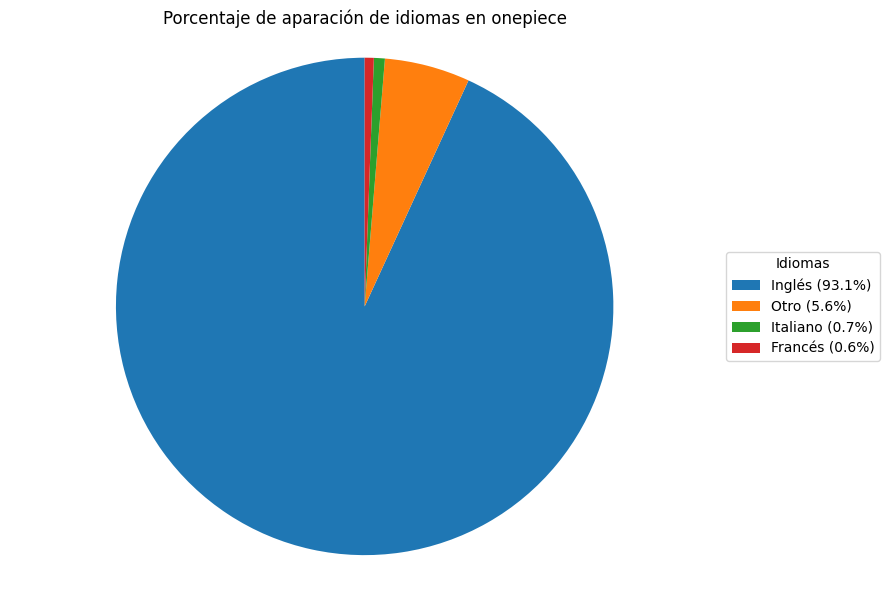


Procesando soccer_final.json...
   Textos válidos: 902
  idioma  frecuencia  porcentaje
0     en         857   95.011086
1   otro          32    3.547672
2     es           7    0.776053
3     it           4    0.443459
4     fr           2    0.221729



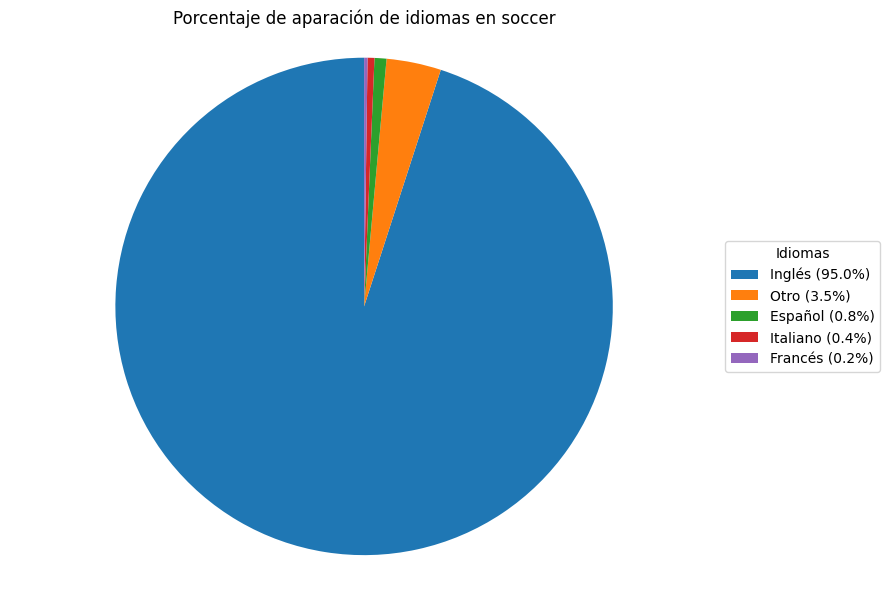


Procesando gaming_final.json...
   Textos válidos: 924
  idioma  frecuencia  porcentaje
0     en         896   96.969697
1   otro          16    1.731602
2     it           5    0.541126
3     fr           4    0.432900
4     es           3    0.324675



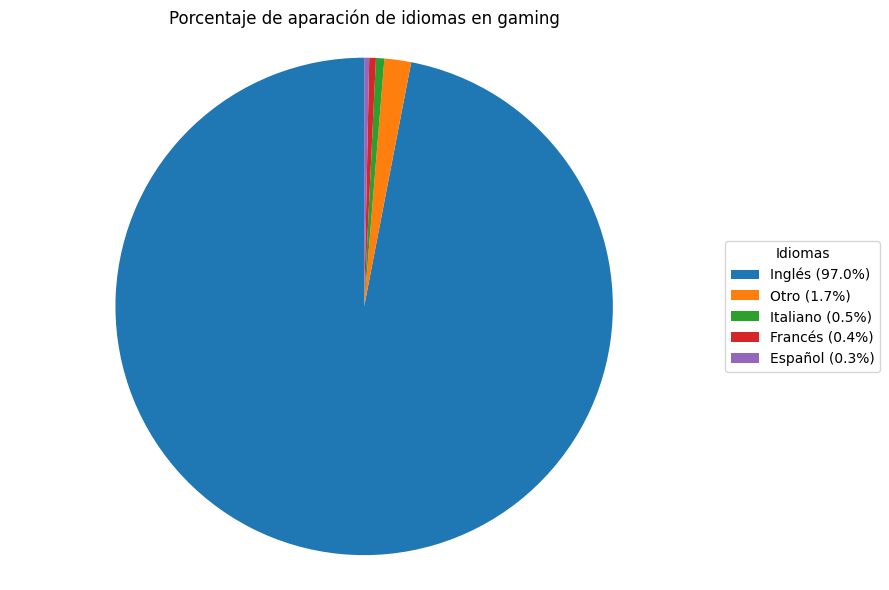


Procesando movies_final.json...
   Textos válidos: 932
  idioma  frecuencia  porcentaje
0     en         905   97.103004
1   otro          25    2.682403
2     fr           2    0.214592



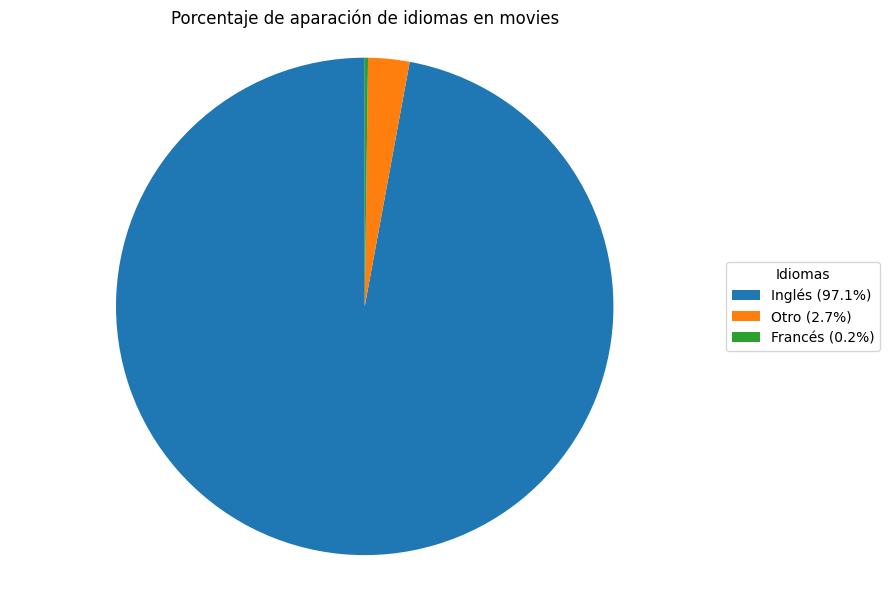


Procesando leagueoflegends_final.json...
   Textos válidos: 957
  idioma  frecuencia  porcentaje
0     en         940   98.223615
1   otro          16    1.671891
2     fr           1    0.104493



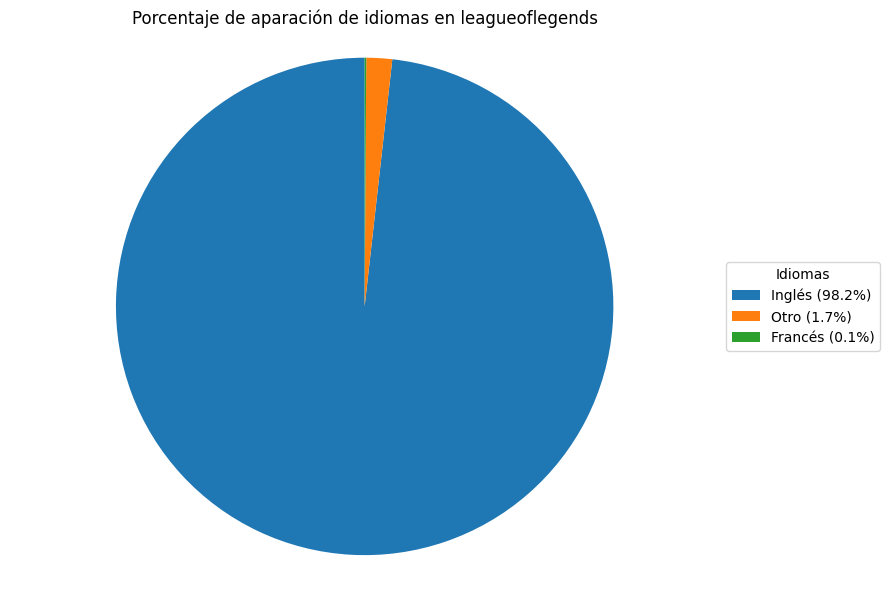


Procesando drawing_final.json...
   Textos válidos: 725
  idioma  frecuencia  porcentaje
0     en         675   93.103448
1   otro          44    6.068966
2     fr           3    0.413793
3     it           2    0.275862
4     es           1    0.137931



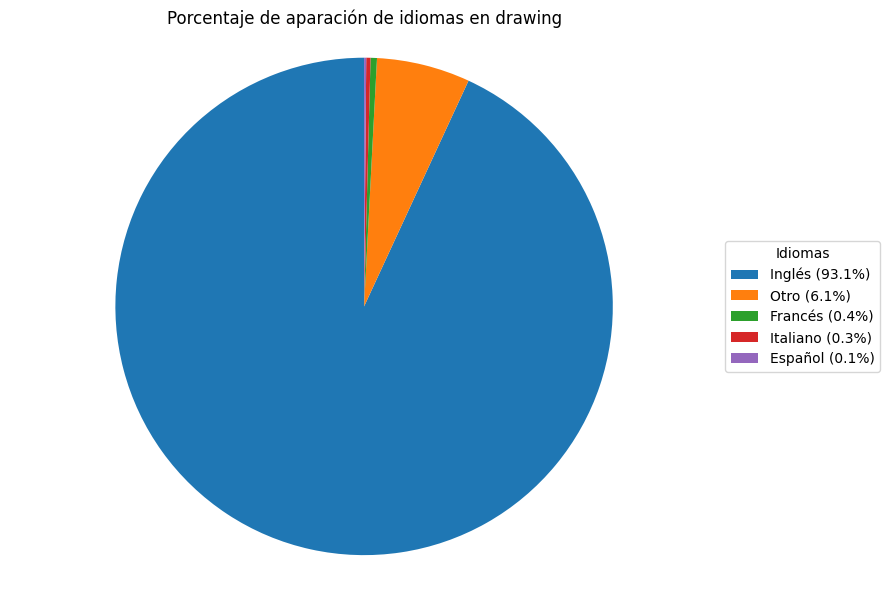

In [95]:
import matplotlib.pyplot as plt
import pandas as pd
import json

# Idiomas principales que queremos mostrar separados
idiomas_principales = ["en", "fr", "es", "it"]

nombres_idiomas = {
    "en": "Inglés",
    "fr": "Francés",
    "es": "Español",
    "it": "Italiano",
    "otro": "Otro"
}


# Recorremos cada subreddit
for subreddit in subreddits:
    filename = subreddit + "_final.json"
    
    print(f"\nProcesando {filename}...")

    with open(filename, "r", encoding="utf-8") as f:
        data = json.load(f)
        
    # Creamos una lista para guardar los textos de cada subreddit
    lista_textos = []
    
    # Recorremos cada submission
    for submission in data["submissions"]:
        
        # Extraemos todo el texto de cada submission (título + descripción) y actualizamos 
        texto_submission = (str(submission.get("title", "")) + " " + str(submission.get("selftext", ""))).strip()

        lista_textos.append(texto_submission)
        
        # Recorremos cada comentario
        for comment in submission["comments"]:
            
            # Extraemos el texto de cada comentario
            texto_comment = str(comment.get("body", "")).strip()

            lista_textos.append(texto_comment)
            
            
    # Creamos un dataframe para guardar los textos del subreddit
    df = pd.DataFrame()

    # Añadimos una columna con los textos extraídos
    df["texto"] = lista_textos

    # Limpiamos los textos
    df["texto_limpio"] = df["texto"].apply(limpiar_texto)
    
    # Quitamos textos cortos de menos de 20 caracteres
    df = df[df["texto_limpio"].str.len() >= 20].copy()

    # Detectamos idioma con la función de antes
    df["idioma"] = df["texto_limpio"].apply(detectar_idioma)
    
    
    # Creamos una lista donde indicamos los idiomas finales de cada texto guardando los idiomas poco frecuentes (los que no hemos definido arriba) en "otro"
    idiomas_finales = []

    for idioma in df["idioma"]:

        if idioma in idiomas_principales:
            idiomas_finales.append(idioma)
        else:
            idiomas_finales.append("otro")

    df["idioma_final"] = idiomas_finales
    

    # Contamos cuánto textos tienen cada idioma
    df_idiomas = df["idioma_final"].value_counts().reset_index()

    # Renombramos las columnas para tener cada idioma y en cuantos textos aparece
    df_idiomas.columns = ["idioma", "frecuencia"]

    # Calculamos el porcentaje que representa cada idioma sobre todos los textos
    df_idiomas["porcentaje"] = (df_idiomas["frecuencia"] / df_idiomas["frecuencia"].sum() * 100)

    # Mostramos el inicio de cada dataframe de idiomas cada subreddit 
    print(f"   Textos válidos: {len(df)}")
    print(df_idiomas.head())
    print()
    
    
    # Finalmente, representamos GRÁFICAMENTE los porcentajes de idiomas para cada subreddit en gráficos de tarta
    etiquetas = []
    
    # Recorremos el dataframe de idiomas de cada subreddit
    for i in range(len(df_idiomas)):
        
        # Obtenemos de cada fila: idioma y porcentaje de aparación
        idioma = df_idiomas.loc[i, "idioma"]
        porcentaje = df_idiomas.loc[i, "porcentaje"]
        
        # Obtenemos el nombre de la lista inicial
        nombre = nombres_idiomas[idioma]

        etiquetas.append(f"{nombre} ({porcentaje:.1f}%)")

    # Gráfico
    plt.figure(figsize=(9, 6))

    wedges, texts = plt.pie(
        df_idiomas["frecuencia"],
        startangle=90
    )

    plt.legend(
        wedges,
        etiquetas,
        title="Idiomas",
        loc="center left",
        bbox_to_anchor=(1, 0.5)
    )

    plt.title(f"Porcentaje de aparación de idiomas en {subreddit}")
    plt.axis("equal")
    plt.tight_layout()
    plt.show()

Los gráficos de tarta finales nos muestran de la distribución lingüística de cada subreddit uno de los subreddits que hemos analizado. En todos los casos, **el inglés aparece como idioma claramente predominante** y con una diferencia muy grande respecto al resto de idiomas, situándose siempre por encima del 90% de los textos e incluso alcanzando valores cercanos al 98% en el subreddit de leagueoflegends o movies. Este resultado era de esperar, ya que Reddit es una plataforma donde la inmnesa mayoría de los usuarios activos hablan en inglés y los subreddits que hemos seleccionado tienen un público muy amplio internacionalmente hablando, es decir, que no tratan un tema típico de un país en concreto.

El segundo bloque de idiomas más grande mostrado en los gráficos corresponde a la categoría “Otro”, donde se agrupan todos los idiomas minoritarios detectados que no aparecían en la lista definida con los idiomas más importantes. Aunque individualmente tienen poco peso, al sumarse en una única categoría alcanzan un gran porcentaje, especialmente en subreddits como drawing u onepiece, donde supera el 5%.

Además se muestran los porcentajes de los idiomas más comunes que indicamos a mano: francés, español e italiano. Aunque hay subreddits donde no se detecta la presencia de ninguno de ellos como por ejemplo el español en leagueoflegends.

<!--  -->

**PALABRAS MÁS FRECUENTES EN TODO EL CORPUS:**

Una de las técnicas de análisis del corpus que vamos a realizar es el cálculo de las palabras más frecuentes en todos los textos. Para ello, se recorren los distintos ficheros JSON de cada subreddit, extrayendo el contenido de los títulos, descripciones y comentarios de cada hilo. Posteriormente, se eliminarán palabras las stopwords y términos demasiado cortos. Y finalmente, se contará cuántas veces aparece cada palabra en el corpus completo, obteniendo así el vocabulario más común.

Primero de todos descargamos stopwords en español e inglés de la librería nltk:

In [6]:
import json
import re
import nltk
import pandas as pd
import matplotlib.pyplot as plt
from nltk.corpus import stopwords

# Descargamos los recursos necesarios para las stopwords
nltk.download('stopwords')

# Cargamos stopwords en inglés y español
stop_words_en = set(stopwords.words('english'))
stop_words_es = set(stopwords.words('spanish'))

# Unimos las stopwords stopwords de ambos idiomas
stop_words = stop_words_en.union(stop_words_es)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jorge\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Ahora, recorreremos cada subreddit y obtenemos las palabras más comunes de todos los subreddits:

In [18]:
from collections import Counter

# Definimos los subreddits
subreddits = ["onepiece", "soccer", "gaming", "movies", "leagueoflegends", "drawing"]

# Creamos un contador vacío para contar el número de veces que aparece cada palabra utilizando la función Counter()
contador_palabras = Counter()

# Recorremos cada subreddit
for subreddit in subreddits:
    filename = subreddit + '_final.json'

    with open(filename, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    # Para cada subreddit, recorremos cada submission
    for submission in data["submissions"]:

        # Obtenemos todo el texto de cada submission juntando el título y la descripción
        texto_submission = (str(submission.get("title", "")) + " " + str(submission.get("selftext", "")))

        # Creamos una lista vacía para guardar el texto de todos los comentarios
        # Recorremos los comentarios de cada submission y almacenamos el cuerpo de cada comentario en la lista
        textos_comentarios = []
        for comment in submission["comments"]:
            textos_comentarios.append(str(comment.get("body", "")))

        # Juntamos todo el texto extraído en un único texto grande que contenga título, descripción y comentarios
        texto_total = texto_submission

        for comentario in textos_comentarios:
            texto_total += " " + comentario

        # Pasamos todo el texto a minúsculas para que se reconozcan palabras iguales como la misma, aunque estén escritas de diferente forma (hola = Hola = HOLA)
        texto_total = texto_total.lower()

        # Extraemos las palabras separando el texto por espacio
        palabras = texto_total.split()

        # Quitamos las stopwords y palabras muy cortas
        # Creamos una lista vacía para guardar las palabras filtradas
        palabras_filtradas = []

        # Recorremos cada palabra
        for palabra in palabras:

            # Si no es stopword y tiene más de 2 letras, la guardamos
            if palabra not in stop_words and len(palabra) > 2:
                palabras_filtradas.append(palabra)
        
        # Actualizamos el contador de palabras
        contador_palabras.update(palabras_filtradas)

# Creamos un DataFrame con las 50 palabras más frecuentes en todo el corpus
df_palabras = pd.DataFrame(
    contador_palabras.most_common(50),     
    columns=["palabra", "frecuencia"]
)

# Mostramos el Dataframe final
df_palabras.T

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
palabra,like,one,would,game,think,get,people,even,good,really,...,something,love,last,lot,well,new,thing,players,since,right
frecuencia,901,577,483,465,435,414,409,394,339,333,...,157,151,148,147,145,145,139,137,136,136


Observando el dataframe obtenido, podemos apreciar que la palabra que aparece con más frecuencia es el término en ingles '**like**', lo cuál tiene sentido pues se utiliza como conector en muchas frases en inglés. En cuánto a las demás palabras que la siguen observamos palabras como '**one**' o '**game**', las cuáles aparecen con más frecuencia debido a que 2 subreddits tratan temas que contienen dicha palabra o derivadas, los cuales son **onepiece** y **gaming**.

Con las palabras más comunes obtenidas, podemos realizar una representación gráfica en formas de gráfico de barras para verlo más detalladamente:

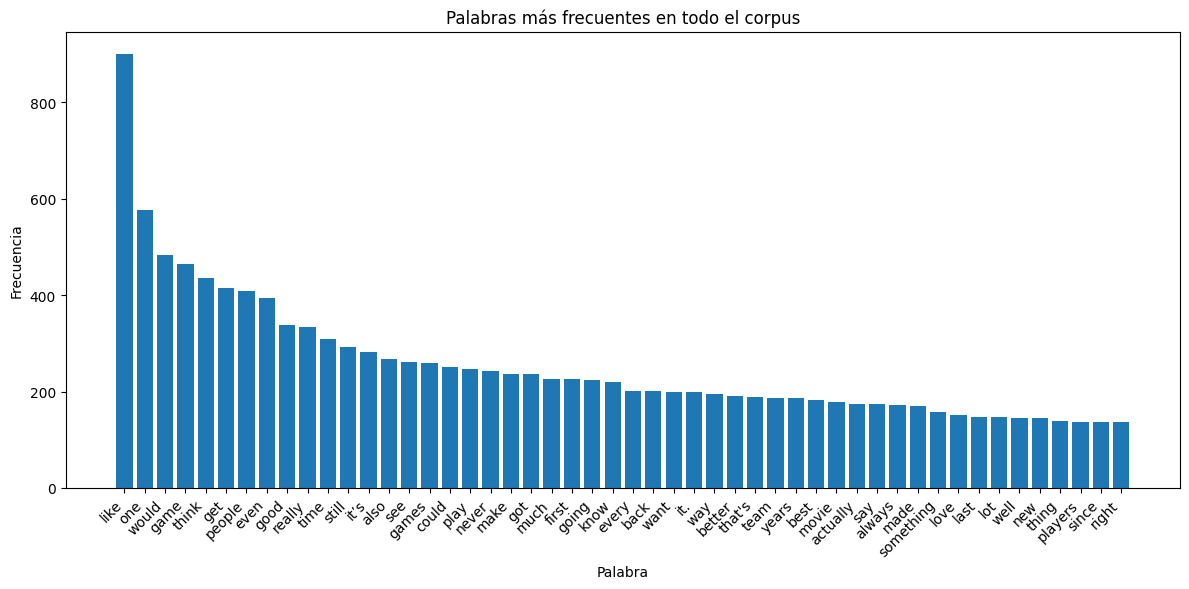

In [14]:
plt.figure(figsize=(12, 6))
plt.bar(df_palabras["palabra"], df_palabras["frecuencia"])
plt.xticks(rotation=45, ha="right")
plt.title("Palabras más frecuentes en todo el corpus")
plt.xlabel("Palabra")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

Por último, vamos a realizar un gráfico de **nube de palabras** donde las palabras más comunes aparecen con mayor tamaño que las menos frecuentes:

In [15]:
# Instalamos la librería necesario si no la tenemos 
# !pip install wordcloud

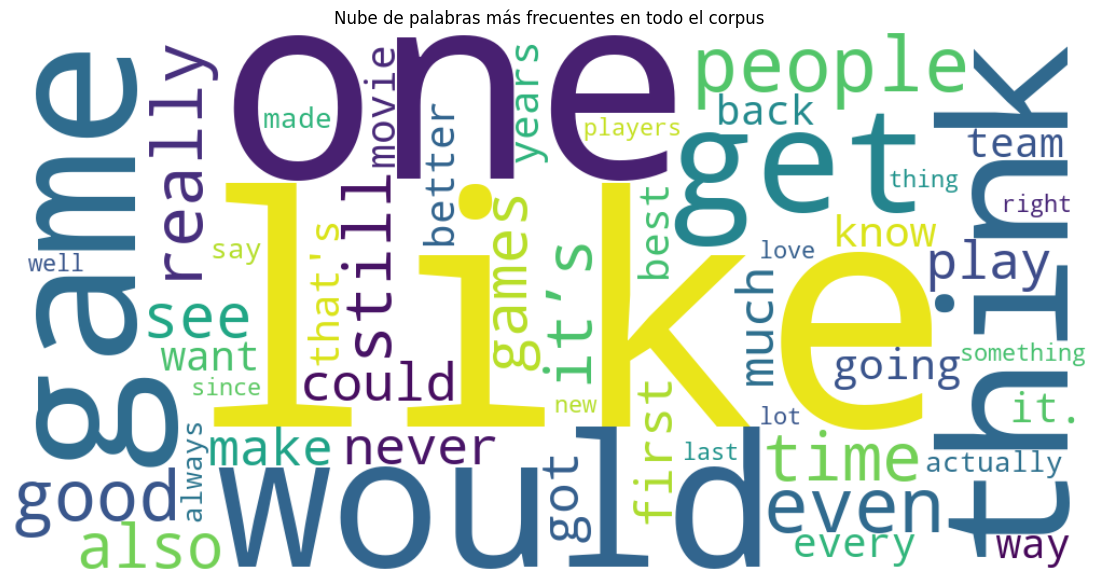

In [16]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Creamos la nube de palabras a partir del contador obtenido
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=50
).generate_from_frequencies(contador_palabras)

# Mostramos gráficamente la nube de palabras obtenida
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras más frecuentes en todo el corpus")
plt.show()

Como volvemos a apreciar ahora en el diagrama de nube, la palabra más grande es '**like**', pues es las que más aparece en todo el corpus, seguida de palabra como 'one', 'game' o 'would'.

<!--  -->

**NÚMERO TOTAL DE PALABRAS EN EL CORPUS**

A continuación, vamos a calcular el número total de palabras que aparecen en el corpus. Tendremos en cuenta todo tipo de textos, tanto el cuerpo de los comentarios, como el título de los hilos, su descripción, etc.

In [54]:
import json

# Definimos los subreddits
subreddits = ["onepiece", "soccer", "gaming", "movies", "leagueoflegends", "drawing"]

# Contador del total de palabras
total_palabras = 0

# Recorremos los subreddits
for subreddit in subreddits:
    filename = subreddit + "_final.json"

    with open(filename, "r", encoding="utf-8") as f:
        data = json.load(f)

    # Recorremos las submissions
    for submission in data["submissions"]:

        # Extraemos las palabras del título de cada submission y las sumamos
        titulo = str(submission.get("title", ""))
        total_palabras += len(titulo.split())

        # Extreamos las palabras de la descripción de cada submission y las sumamos
        selftext = str(submission.get("selftext", ""))
        total_palabras += len(selftext.split())

        # Recorremos cada comentario
        for comment in submission["comments"]:

            # Extraemos las palabras del cuerpo de cada comentario y las sumamos 
            cuerpo = str(comment.get("body", ""))
            total_palabras += len(cuerpo.split())

# Finalmente, tras recorrer todos los comentarios de todas las submissions de todos los subreddits, motramos el resultado final
print("Número total de palabras del corpus:", total_palabras)

Número total de palabras del corpus: 170092


Como vemos, aparecen un total de 170.092 palabras en todo el corpus.

<!--  -->

**NÚMERO DE PALABRAS MEDIO POR COMENTARIO**

A continuación, vamos a calcular cuántas palabras aparecen de media en cada comentario de todos los subreddits:

In [55]:
import json

# Definimos los subreddits
subreddits = ["onepiece", "soccer", "gaming", "movies", "leagueoflegends", "drawing"]

# Creamos un contador para el número total de palabras y otro contador para el número total de comentarios
total_palabras = 0
total_comentarios = 0

# Recorremos los subreddits
for subreddit in subreddits:
    filename = subreddit + "_final.json"

    with open(filename, "r", encoding="utf-8") as f:
        data = json.load(f)

    # Recorremos las submissions
    for submission in data["submissions"]:

        # Recorremos cada comentario de todas las submissions de todos los subreddits
        for comment in submission["comments"]:

            # Obtenemos el cuerpo de cada comentario
            cuerpo = str(comment.get("body", ""))

            # Obteneme una lista con las palabras que contiene cada comentario 
            palabras = cuerpo.split()

            # Añadimos al contador de palabras total las palabras de cada comentario
            total_palabras += len(palabras)

            # Sumamos 1 al número de comentarios leídos 
            total_comentarios += 1

# Calculamos la media palabras por comentario. Para ello dividimos el total de palabras del corpus entre el total de comentarios del corpus.
media_palabras = total_palabras / total_comentarios

# Mostrar resultado
print("Número total de comentarios:", total_comentarios)
print("Número total de palabras en los comentarios:", total_palabras)
print("Número medio de palabras por comentario:", round(media_palabras))

Número total de comentarios: 6000
Número total de palabras en los comentarios: 147867
Número medio de palabras por comentario: 25


<!--  -->

**NÚMERO DE PALABRAS MEDIO POR SUBMISSION**

A continuación, vamos a calcular cuántas palabras aparecen de media en cada submission:

In [56]:
import json

# Definimos los subreddits
subreddits = ["onepiece", "soccer", "gaming", "movies", "leagueoflegends", "drawing"]

# Creamos dos contadores, uno para palabras y otro para submissions
total_palabras = 0
total_submissions = 0

# Recorremos los subreddits
for subreddit in subreddits:
    filename = subreddit + "_final.json"

    with open(filename, "r", encoding="utf-8") as f:
        data = json.load(f)

    # Recorremos las submissions
    for submission in data["submissions"]:

        palabras_submission = 0

        # Contamos las palabras del título y las sumamos
        titulo = str(submission.get("title", ""))
        palabras_submission += len(titulo.split())

        # Contamos palabras de la descripción y las sumamos
        selftext = str(submission.get("selftext", ""))
        palabras_submission += len(selftext.split())

        # Recorremos los comentarios de esa submissions
        for comment in submission["comments"]:
            
            # Sumamos las palabras del cuerpo de los comentarios de esa submission
            cuerpo = str(comment.get("body", ""))
            palabras_submission += len(cuerpo.split())

        # Sumamos al total de palabras las palabras de cada submission
        total_palabras += palabras_submission

        # Añadimos 1 al número de submissions
        total_submissions += 1

# Calculamos la media de palabras que aparecen en cada submission
media_palabras_submission = total_palabras / total_submissions

# Mostramos los resultados
print("Número total de submissions:", total_submissions)
print("Número total de palabras:", total_palabras)
print("Número medio de palabras por submission:", round(media_palabras_submission))

Número total de submissions: 240
Número total de palabras: 170092
Número medio de palabras por submission: 709


<!--  -->

**NÚMERO DE PALABRAS POR SUBREDDIT**

A continuación, vamos a calcular cuántas palabras aparecen en cada subreddit:

In [59]:
import json
import pandas as pd

# Definimos los subreddits
subreddits = ["onepiece", "soccer", "gaming", "movies", "leagueoflegends", "drawing"]

# Creamos una lista para guardar resultados
resultados = []

# Recorremos los subreddits
for subreddit in subreddits:
    filename = subreddit + "_final.json"

    with open(filename, "r", encoding="utf-8") as f:
        data = json.load(f)

    total_palabras = 0

    # Recorremos las submissions 
    for submission in data["submissions"]:
        
        # Extraemos las palabras del título de cada submission y las sumamos
        titulo = str(submission.get("title", ""))
        total_palabras += len(titulo.split())

        # Extreamos las palabras de la descripción de cada submission y las sumamos
        selftext = str(submission.get("selftext", ""))
        total_palabras += len(selftext.split())

        # Recorremos cada comentario
        for comment in submission["comments"]:

            # Extraemos las palabras del cuerpo de cada comentario y las sumamos 
            cuerpo = str(comment.get("body", ""))
            total_palabras += len(cuerpo.split())
    
    # Añadimos a la lista de resultados tanto el subreddit actual como su número total de palabras
    resultados.append([subreddit, total_palabras])

# Creamos un DataFrame para mostrar el número total de palabras que hay en cada subreddit
df_medias = pd.DataFrame(
    resultados,
    columns=["subreddit", "media_palabras"]
)

df_medias

,subreddit,media_palabras
0,onepiece,25147
1,soccer,28011
2,gaming,31639
3,movies,26521
4,leagueoflegends,41984
5,drawing,16790


Longitud media de las palabras por cada subreddit